Optimization terminated successfully.
         Current function value: 0.374315
         Iterations: 59
         Function evaluations: 106
Optimization Results
Membrane stiffness k_m: 0.2850
Joint stiffness k_j:    0.2990
Wing area S:            0.0170 m^2
Mean lift:              0.9799 N
Required weight:        0.9810 N
Mean drag:              0.2496 N
Power proxy:            2.4914 W
Cost of transport:      0.6349
Max membrane camber:    0.0983 rad
Max passive joint def.: 0.3939 rad


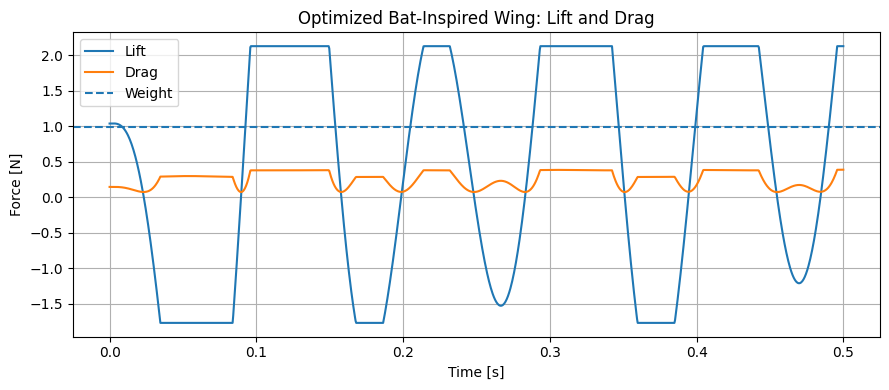

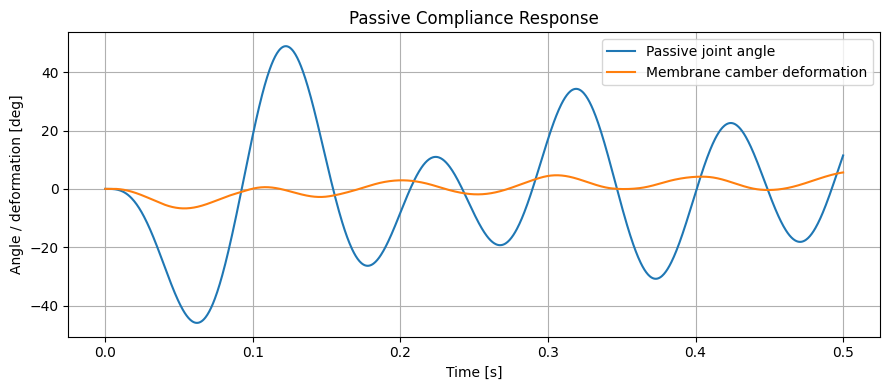

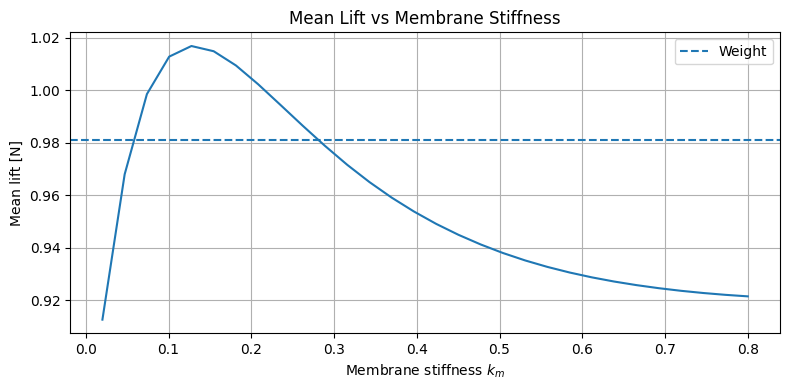

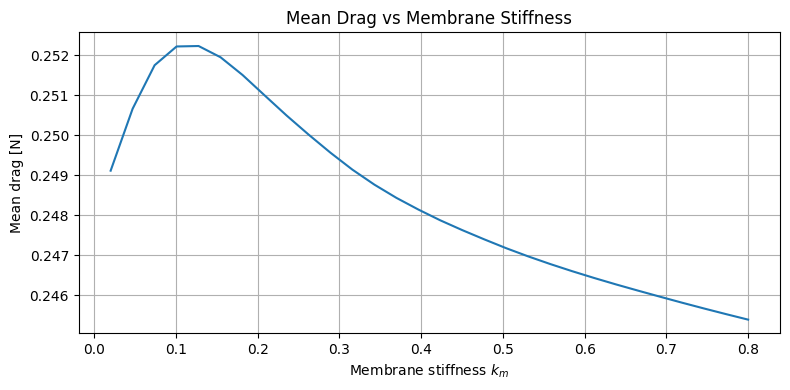

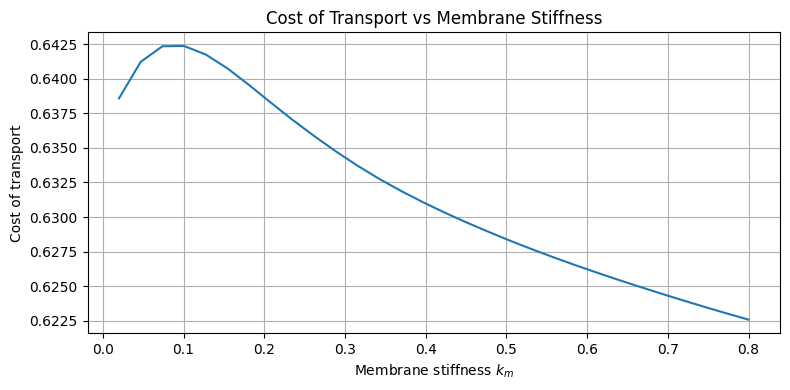

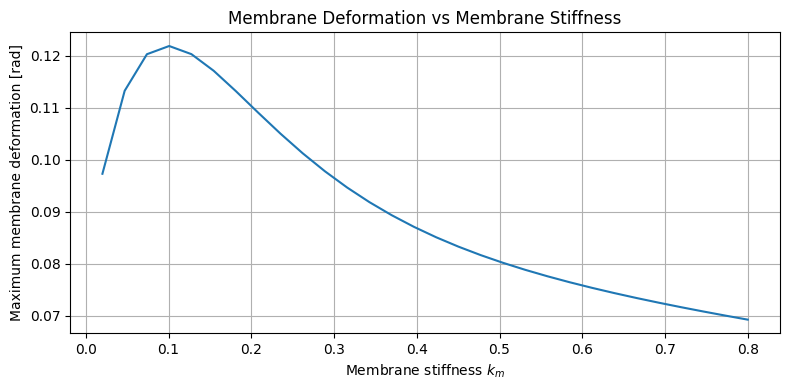

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# Bat-inspired passive compliance optimization
# Design variables:
#   x = [membrane_stiffness, joint_stiffness, wing_area]
#
# Simplified dynamics inspired by:
#   M(q) qddot + D qdot + K q = Q_aero
#
# Passive states:
#   theta = passive folding / pitch angle
#   eta   = passive membrane camber deformation

# Constants

rho = 1.225          # air density [kg/m^3]
U_forward = 4.0      # forward flight speed [m/s]
mass = 0.10          # robot mass [kg]
g = 9.81             # gravity [m/s^2]
weight = mass * g

freq = 10.0          # flapping frequency [Hz]
omega = 2 * np.pi * freq
T = 1 / freq         # one flapping period

phi_amp = np.deg2rad(45)   # flapping amplitude
theta0 = np.deg2rad(8)     # nominal angle of attack

chord_ref = 0.08     # reference chord [m]
span_ref = 0.40      # reference wingspan [m]

# Passive inertia terms
I_theta = 2.0e-4
I_eta = 1.0e-4

# Damping terms
d_theta = 2.0e-3
d_eta = 1.0e-3

# Optimization weights
drag_weight = 1.0
power_weight = 0.05
lift_penalty_weight = 100.0
deformation_penalty_weight = 5.0


# Prescribed flapping kinematics

def flapping_angle(t):
    return phi_amp * np.sin(omega * t)

def flapping_rate(t):
    return phi_amp * omega * np.cos(omega * t)

def flapping_accel(t):
    return -phi_amp * omega**2 * np.sin(omega * t)


# Aerodynamic model
def aero_forces(theta, eta, theta_dot, eta_dot, wing_area):
    """
    Simplified quasi-steady aerodynamic model.

    theta = passive folding / pitch angle
    eta   = passive membrane camber

    More camber increases lift, but excessive camber increases drag.
    """

    V_eff = np.sqrt(U_forward**2 + (span_ref * omega * phi_amp / 2)**2)

    alpha_eff = theta0 + theta + 0.6 * eta

    CL = 2 * np.pi * alpha_eff
    CL = np.clip(CL, -1.5, 1.8)

    CD0 = 0.06
    induced_drag = 0.08 * CL**2
    camber_drag = 0.8 * eta**2
    CD = CD0 + induced_drag + camber_drag

    q_dyn = 0.5 * rho * V_eff**2

    lift = q_dyn * wing_area * CL
    drag = q_dyn * wing_area * CD

    # Aerodynamic generalized forcing on passive coordinates
    Q_theta = 0.015 * lift - 0.02 * drag
    Q_eta = 0.020 * lift - 0.030 * eta_dot

    return lift, drag, Q_theta, Q_eta, CL, CD

# Passive dynamics
def passive_dynamics(t, z, membrane_stiffness, joint_stiffness, wing_area):
    """
    z = [theta, eta, theta_dot, eta_dot]
    """

    theta, eta, theta_dot, eta_dot = z

    lift, drag, Q_theta, Q_eta, CL, CD = aero_forces(
        theta, eta, theta_dot, eta_dot, wing_area
    )

    # Prescribed flapping excitation
    phi_ddot = flapping_accel(t)

    # Coupling from flapping acceleration into passive deformation
    coupling_theta = 0.00008 * phi_ddot
    coupling_eta = 0.00004 * phi_ddot

    # Lagrangian-inspired passive equations:
    # I*qddot + d*qdot + k*q = Q_aero + coupling
    theta_ddot = (
        Q_theta
        + coupling_theta
        - d_theta * theta_dot
        - joint_stiffness * theta
    ) / I_theta

    eta_ddot = (
        Q_eta
        + coupling_eta
        - d_eta * eta_dot
        - membrane_stiffness * eta
    ) / I_eta

    return [theta_dot, eta_dot, theta_ddot, eta_ddot]

# Simulate one design
def simulate_design(x, n_cycles=5, n_points=1200):
    membrane_stiffness, joint_stiffness, wing_area = x

    t_final = n_cycles * T
    t_eval = np.linspace(0, t_final, n_points)

    z0 = [0.0, 0.0, 0.0, 0.0]

    sol = solve_ivp(
        passive_dynamics,
        [0, t_final],
        z0,
        t_eval=t_eval,
        args=(membrane_stiffness, joint_stiffness, wing_area),
        rtol=1e-7,
        atol=1e-9
    )

    theta = sol.y[0]
    eta = sol.y[1]
    theta_dot = sol.y[2]
    eta_dot = sol.y[3]
    t = sol.t

    lift = np.zeros_like(t)
    drag = np.zeros_like(t)
    CL = np.zeros_like(t)
    CD = np.zeros_like(t)

    for i in range(len(t)):
        lift[i], drag[i], _, _, CL[i], CD[i] = aero_forces(
            theta[i], eta[i], theta_dot[i], eta_dot[i], wing_area
        )

    # Use final cycle for performance metrics
    final_cycle_mask = t >= (t_final - T)

    t_c = t[final_cycle_mask]
    lift_c = lift[final_cycle_mask]
    drag_c = drag[final_cycle_mask]
    theta_c = theta[final_cycle_mask]
    eta_c = eta[final_cycle_mask]
    theta_dot_c = theta_dot[final_cycle_mask]
    eta_dot_c = eta_dot[final_cycle_mask]

    mean_lift = np.mean(lift_c)
    mean_drag = np.mean(drag_c)

    # Mechanical power proxy from passive springs/dampers + drag power
    membrane_stiffness, joint_stiffness, wing_area = x

    spring_power = (
        joint_stiffness * theta_c * theta_dot_c
        + membrane_stiffness * eta_c * eta_dot_c
    )

    damping_power = (
        d_theta * theta_dot_c**2
        + d_eta * eta_dot_c**2
    )

    drag_power = mean_drag * U_forward

    power = np.mean(np.abs(spring_power)) + np.mean(damping_power) + drag_power

    cost_of_transport = power / (mass * g * U_forward)

    max_eta = np.max(np.abs(eta_c))
    max_theta = np.max(np.abs(theta_c))

    return {
        "t": t,
        "theta": theta,
        "eta": eta,
        "theta_dot": theta_dot,
        "eta_dot": eta_dot,
        "lift": lift,
        "drag": drag,
        "CL": CL,
        "CD": CD,
        "mean_lift": mean_lift,
        "mean_drag": mean_drag,
        "power": power,
        "cost_of_transport": cost_of_transport,
        "max_eta": max_eta,
        "max_theta": max_theta,
        "success": sol.success
    }


# Objective function
def objective(x):
    result = simulate_design(x)

    mean_lift = result["mean_lift"]
    mean_drag = result["mean_drag"]
    power = result["power"]
    max_eta = result["max_eta"]

    # Penalize designs that cannot support weight
    lift_error = max(0.0, weight - mean_lift)

    # Penalize excessive membrane deformation
    deformation_penalty = max(0.0, max_eta - 0.30)

    J = (
        drag_weight * mean_drag
        + power_weight * power
        + lift_penalty_weight * lift_error**2
        + deformation_penalty_weight * deformation_penalty**2
    )

    return J


# ------------------------------------------------------------
# Run optimization
# ------------------------------------------------------------

bounds = [
    (0.02, 0.80),   # membrane stiffness
    (0.02, 1.20),   # joint stiffness
    (0.015, 0.080)  # wing area
]

x0 = np.array([0.20, 0.30, 0.040])

opt = minimize(
    objective,
    x0,
    method="Nelder-Mead",
    options={
        "maxiter": 120,
        "xatol": 1e-4,
        "fatol": 1e-4,
        "disp": True
    }
)

x_opt = opt.x
result_opt = simulate_design(x_opt)

print("Optimization Results")
print(f"Membrane stiffness k_m: {x_opt[0]:.4f}")
print(f"Joint stiffness k_j:    {x_opt[1]:.4f}")
print(f"Wing area S:            {x_opt[2]:.4f} m^2")
print(f"Mean lift:              {result_opt['mean_lift']:.4f} N")
print(f"Required weight:        {weight:.4f} N")
print(f"Mean drag:              {result_opt['mean_drag']:.4f} N")
print(f"Power proxy:            {result_opt['power']:.4f} W")
print(f"Cost of transport:      {result_opt['cost_of_transport']:.4f}")
print(f"Max membrane camber:    {result_opt['max_eta']:.4f} rad")
print(f"Max passive joint def.: {result_opt['max_theta']:.4f} rad")


# Plot optimized time histories
t = result_opt["t"]

plt.figure(figsize=(9, 4))
plt.plot(t, result_opt["lift"], label="Lift")
plt.plot(t, result_opt["drag"], label="Drag")
plt.axhline(weight, linestyle="--", label="Weight")
plt.xlabel("Time [s]")
plt.ylabel("Force [N]")
plt.title("Optimized Bat-Inspired Wing: Lift and Drag")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(t, np.rad2deg(result_opt["theta"]), label="Passive joint angle")
plt.plot(t, np.rad2deg(result_opt["eta"]), label="Membrane camber deformation")
plt.xlabel("Time [s]")
plt.ylabel("Angle / deformation [deg]")
plt.title("Passive Compliance Response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Parameter sweep for preliminary-results plots
membrane_values = np.linspace(0.02, 0.80, 30)

mean_lifts = []
mean_drags = []
cots = []
max_etas = []

for km in membrane_values:
    x_test = [km, x_opt[1], x_opt[2]]
    r = simulate_design(x_test)

    mean_lifts.append(r["mean_lift"])
    mean_drags.append(r["mean_drag"])
    cots.append(r["cost_of_transport"])
    max_etas.append(r["max_eta"])

mean_lifts = np.array(mean_lifts)
mean_drags = np.array(mean_drags)
cots = np.array(cots)
max_etas = np.array(max_etas)

plt.figure(figsize=(8, 4))
plt.plot(membrane_values, mean_lifts)
plt.axhline(weight, linestyle="--", label="Weight")
plt.xlabel("Membrane stiffness $k_m$")
plt.ylabel("Mean lift [N]")
plt.title("Mean Lift vs Membrane Stiffness")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(membrane_values, mean_drags)
plt.xlabel("Membrane stiffness $k_m$")
plt.ylabel("Mean drag [N]")
plt.title("Mean Drag vs Membrane Stiffness")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(membrane_values, cots)
plt.xlabel("Membrane stiffness $k_m$")
plt.ylabel("Cost of transport")
plt.title("Cost of Transport vs Membrane Stiffness")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(membrane_values, max_etas)
plt.xlabel("Membrane stiffness $k_m$")
plt.ylabel("Maximum membrane deformation [rad]")
plt.title("Membrane Deformation vs Membrane Stiffness")
plt.grid(True)
plt.tight_layout()
plt.show()

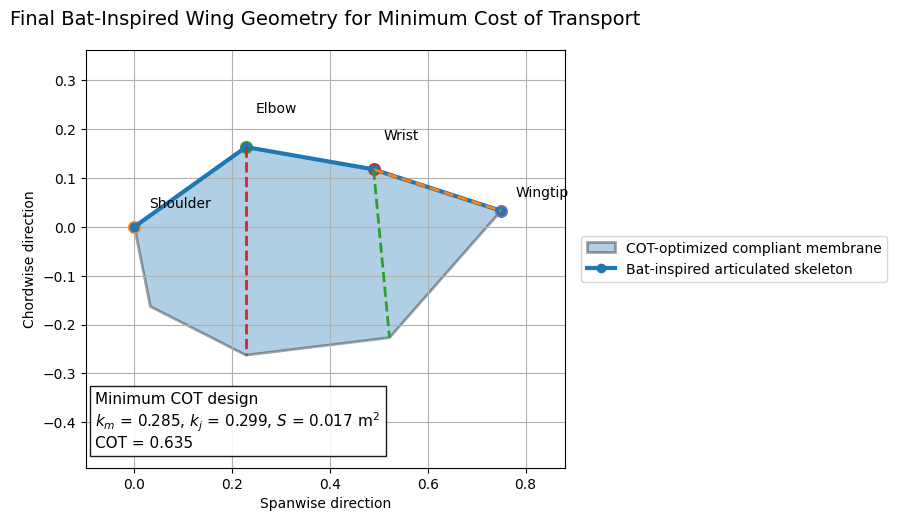

In [28]:
# Wing Geometry for Minimum Cost of Transport

def plot_cot_optimized_wing_geometry(x, result):
    km, kj, S = x

    scale = np.sqrt(S / 0.040)

    shoulder = np.array([0.0, 0.0])
    elbow    = scale * np.array([0.35, 0.25])
    wrist    = scale * np.array([0.75, 0.18])
    wingtip  = scale * np.array([1.15, 0.05])

    body_trailing  = scale * np.array([0.05, -0.25])
    inner_trailing = scale * np.array([0.35, -0.35])
    outer_trailing = scale * np.array([0.80, -0.28])

    eta_vis = result["max_eta"]

    inner_trailing_deformed = inner_trailing + np.array([0.0, -0.35 * eta_vis])
    outer_trailing_deformed = outer_trailing + np.array([0.0, -0.45 * eta_vis])

    membrane = np.array([
        shoulder,
        elbow,
        wrist,
        wingtip,
        outer_trailing_deformed,
        inner_trailing_deformed,
        body_trailing
    ])

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.fill(
        membrane[:, 0],
        membrane[:, 1],
        alpha=0.35,
        edgecolor="black",
        linewidth=2,
        label="COT-optimized compliant membrane"
    )

    leading_edge = np.array([shoulder, elbow, wrist, wingtip])

    ax.plot(
        leading_edge[:, 0],
        leading_edge[:, 1],
        marker="o",
        linewidth=3,
        label="Bat-inspired articulated skeleton"
    )

    digits = [
        np.array([wrist, wingtip]),
        np.array([wrist, outer_trailing_deformed]),
        np.array([elbow, inner_trailing_deformed])
    ]

    for digit in digits:
        ax.plot(digit[:, 0], digit[:, 1], "--", linewidth=2)

    label_offsets = {
        "Shoulder": np.array([0.03, 0.04]),
        "Elbow": np.array([0.02, 0.07]),
        "Wrist": np.array([0.02, 0.06]),
        "Wingtip": np.array([0.03, 0.03])
    }

    points = {
        "Shoulder": shoulder,
        "Elbow": elbow,
        "Wrist": wrist,
        "Wingtip": wingtip
    }

    for name, pt in points.items():
        ax.scatter(pt[0], pt[1], s=70)
        offset = label_offsets[name]
        ax.text(pt[0] + offset[0], pt[1] + offset[1], name, fontsize=10)

    # Text box placed in axes coordinates, not data coordinates
    ax.text(
        0.02,
        0.04,
        f"Minimum COT design\n"
        f"$k_m$ = {km:.3f}, $k_j$ = {kj:.3f}, $S$ = {S:.3f} m$^2$\n"
        f"COT = {result['cost_of_transport']:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="bottom",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
    )

    ax.set_title(
        "Final Bat-Inspired Wing Geometry for Minimum Cost of Transport",
        fontsize=14,
        pad=18
    )

    ax.set_xlabel("Spanwise direction")
    ax.set_ylabel("Chordwise direction")
    ax.axis("equal")
    ax.grid(True)

    # Add extra space so the wing is not cramped
    ax.set_xlim(-0.10, 1.35 * scale)
    ax.set_ylim(-0.55 * scale, 0.35 * scale)

    # Legend outside plot
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


plot_cot_optimized_wing_geometry(x_opt, result_opt)

In [29]:
# Maximize Forward Displacement + Plot Final Geometry
def forward_displacement_objective(x):
    r = simulate_design(x)

    mean_drag = r["mean_drag"]
    mean_lift = r["mean_lift"]
    max_eta = r["max_eta"]

    thrust_proxy = 0.75 * mean_lift * max_eta - 0.35 * mean_drag
    dx = thrust_proxy / mass * T**2

    lift_penalty = max(0.0, weight - mean_lift)**2
    deformation_penalty = max(0.0, max_eta - 0.30)**2
    negative_thrust_penalty = max(0.0, -thrust_proxy)**2

    return (
        -dx
        + 100.0 * lift_penalty
        + 20.0 * deformation_penalty
        + 50.0 * negative_thrust_penalty
    )


opt_dx = minimize(
    forward_displacement_objective,
    x0,
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "maxiter": 200,
        "ftol": 1e-8
    }
)

x_dx = opt_dx.x
result_dx = simulate_design(x_dx)

mean_drag = result_dx["mean_drag"]
mean_lift = result_dx["mean_lift"]
max_eta = result_dx["max_eta"]

thrust_proxy = 0.75 * mean_lift * max_eta - 0.35 * mean_drag
max_forward_displacement = thrust_proxy / mass * T**2

print("Maximum Forward Displacement Design")
print(f"Optimizer success:            {opt_dx.success}")
print(f"Optimizer message:            {opt_dx.message}")
print(f"Membrane stiffness k_m:       {x_dx[0]:.4f}")
print(f"Joint stiffness k_j:          {x_dx[1]:.4f}")
print(f"Wing area S:                  {x_dx[2]:.4f} m^2")
print(f"Mean lift:                    {mean_lift:.4f} N")
print(f"Required weight:              {weight:.4f} N")
print(f"Mean drag:                    {mean_drag:.4f} N")
print(f"Estimated thrust proxy:       {thrust_proxy:.4f} N")
print(f"Max forward displacement dx:  {max_forward_displacement:.6f} m/cycle")
print(f"Max membrane deformation eta: {max_eta:.4f} rad")

Maximum Forward Displacement Design
Optimizer success:            True
Optimizer message:            CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Membrane stiffness k_m:       0.1990
Joint stiffness k_j:          0.2984
Wing area S:                  0.0399 m^2
Mean lift:                    3.2423 N
Required weight:              0.9810 N
Mean drag:                    0.8295 N
Estimated thrust proxy:       0.5452 N
Max forward displacement dx:  0.054517 m/cycle
Max membrane deformation eta: 0.3436 rad


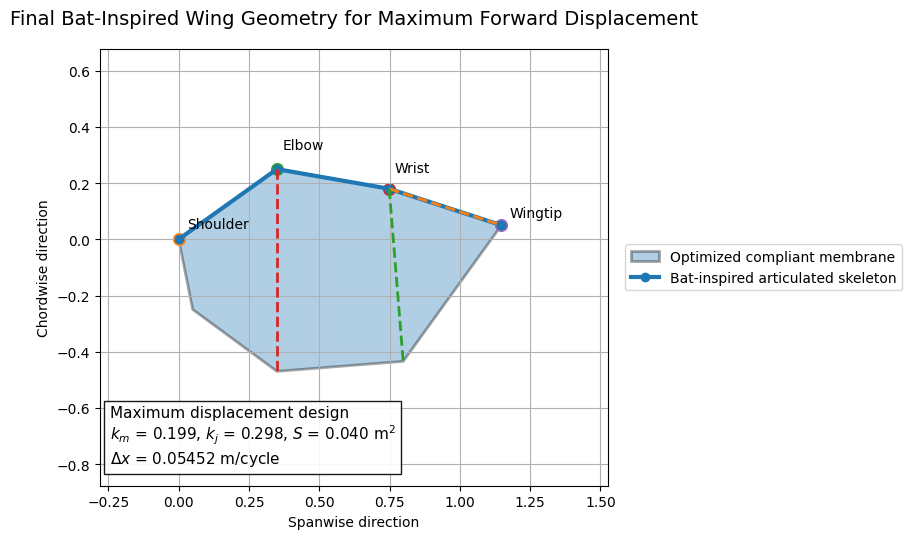

In [30]:
# Wing Geometry for Maximum Forward Displacement
def plot_bat_wing_geometry(x, result):
    km, kj, S = x

    scale = np.sqrt(S / 0.040)

    shoulder = np.array([0.0, 0.0])
    elbow    = scale * np.array([0.35, 0.25])
    wrist    = scale * np.array([0.75, 0.18])
    wingtip  = scale * np.array([1.15, 0.05])

    body_trailing  = scale * np.array([0.05, -0.25])
    inner_trailing = scale * np.array([0.35, -0.35])
    outer_trailing = scale * np.array([0.80, -0.28])

    eta_vis = result["max_eta"]

    inner_trailing_deformed = inner_trailing + np.array([0.0, -0.35 * eta_vis])
    outer_trailing_deformed = outer_trailing + np.array([0.0, -0.45 * eta_vis])

    membrane = np.array([
        shoulder,
        elbow,
        wrist,
        wingtip,
        outer_trailing_deformed,
        inner_trailing_deformed,
        body_trailing
    ])

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.fill(
        membrane[:, 0],
        membrane[:, 1],
        alpha=0.35,
        edgecolor="black",
        linewidth=2,
        label="Optimized compliant membrane"
    )

    leading_edge = np.array([shoulder, elbow, wrist, wingtip])

    ax.plot(
        leading_edge[:, 0],
        leading_edge[:, 1],
        marker="o",
        linewidth=3,
        label="Bat-inspired articulated skeleton"
    )

    digits = [
        np.array([wrist, wingtip]),
        np.array([wrist, outer_trailing_deformed]),
        np.array([elbow, inner_trailing_deformed])
    ]

    for digit in digits:
        ax.plot(digit[:, 0], digit[:, 1], "--", linewidth=2)

    label_offsets = {
        "Shoulder": np.array([0.03, 0.04]),
        "Elbow": np.array([0.02, 0.07]),
        "Wrist": np.array([0.02, 0.06]),
        "Wingtip": np.array([0.03, 0.03])
    }

    points = {
        "Shoulder": shoulder,
        "Elbow": elbow,
        "Wrist": wrist,
        "Wingtip": wingtip
    }

    for name, pt in points.items():
        ax.scatter(pt[0], pt[1], s=70)
        offset = label_offsets[name]
        ax.text(pt[0] + offset[0], pt[1] + offset[1], name, fontsize=10)

    ax.text(
        0.02,
        0.04,
        f"Maximum displacement design\n"
        f"$k_m$ = {km:.3f}, $k_j$ = {kj:.3f}, $S$ = {S:.3f} m$^2$\n"
        f"$\\Delta x$ = {max_forward_displacement:.5f} m/cycle",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="bottom",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
    )

    ax.set_title(
        "Final Bat-Inspired Wing Geometry for Maximum Forward Displacement",
        fontsize=14,
        pad=18
    )

    ax.set_xlabel("Spanwise direction")
    ax.set_ylabel("Chordwise direction")
    ax.axis("equal")
    ax.grid(True)

    ax.set_xlim(-0.10, 1.35 * scale)
    ax.set_ylim(-0.55 * scale, 0.35 * scale)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


plot_bat_wing_geometry(x_dx, result_dx)

Maximum Lift-to-Drag Ratio Design
Optimizer success:            True
Optimizer message:            CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Membrane stiffness k_m:       0.2696
Joint stiffness k_j:          0.3837
Wing area S:                  0.0437 m^2
Mean lift:                    4.5157 N
Required weight:              0.9810 N
Mean drag:                    0.8367 N
Lift-to-drag ratio L/D:       5.3968
Max membrane deformation eta: 0.2756 rad


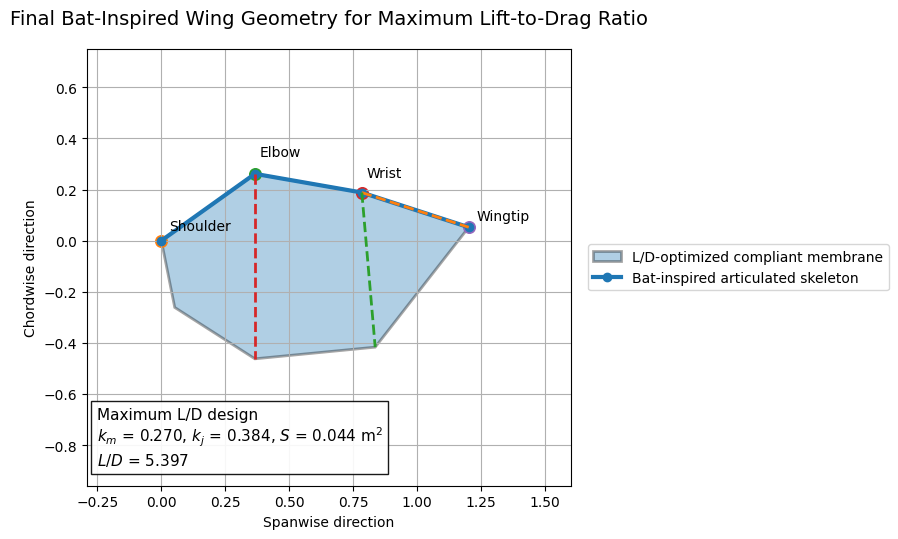

In [31]:
# Maximize Lift-to-Drag Ratio + Plot Final Geometry
def lift_to_drag_objective(x):
    r = simulate_design(x)

    mean_lift = r["mean_lift"]
    mean_drag = r["mean_drag"]
    max_eta = r["max_eta"]

    # Avoid division by zero
    lift_to_drag = mean_lift / (mean_drag + 1e-8)

    # Constraints/penalties
    lift_penalty = max(0.0, weight - mean_lift)**2
    deformation_penalty = max(0.0, max_eta - 0.30)**2

    # Since scipy minimizes, use negative L/D
    return (
        -lift_to_drag
        + 100.0 * lift_penalty
        + 20.0 * deformation_penalty
    )

# Optimize for maximum lift-to-drag ratio
opt_ld = minimize(
    lift_to_drag_objective,
    x0,
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "maxiter": 200,
        "ftol": 1e-8
    }
)

x_ld = opt_ld.x
result_ld = simulate_design(x_ld)

mean_lift_ld = result_ld["mean_lift"]
mean_drag_ld = result_ld["mean_drag"]
max_eta_ld = result_ld["max_eta"]
lift_to_drag_ld = mean_lift_ld / (mean_drag_ld + 1e-8)

print("Maximum Lift-to-Drag Ratio Design")
print(f"Optimizer success:            {opt_ld.success}")
print(f"Optimizer message:            {opt_ld.message}")
print(f"Membrane stiffness k_m:       {x_ld[0]:.4f}")
print(f"Joint stiffness k_j:          {x_ld[1]:.4f}")
print(f"Wing area S:                  {x_ld[2]:.4f} m^2")
print(f"Mean lift:                    {mean_lift_ld:.4f} N")
print(f"Required weight:              {weight:.4f} N")
print(f"Mean drag:                    {mean_drag_ld:.4f} N")
print(f"Lift-to-drag ratio L/D:       {lift_to_drag_ld:.4f}")
print(f"Max membrane deformation eta: {max_eta_ld:.4f} rad")


# Plot final wing geometry for max L/D design
def plot_ld_optimized_wing_geometry(x, result):
    km, kj, S = x

    scale = np.sqrt(S / 0.040)

    shoulder = np.array([0.0, 0.0])
    elbow    = scale * np.array([0.35, 0.25])
    wrist    = scale * np.array([0.75, 0.18])
    wingtip  = scale * np.array([1.15, 0.05])

    body_trailing  = scale * np.array([0.05, -0.25])
    inner_trailing = scale * np.array([0.35, -0.35])
    outer_trailing = scale * np.array([0.80, -0.28])

    eta_vis = result["max_eta"]

    inner_trailing_deformed = inner_trailing + np.array([0.0, -0.35 * eta_vis])
    outer_trailing_deformed = outer_trailing + np.array([0.0, -0.45 * eta_vis])

    membrane = np.array([
        shoulder,
        elbow,
        wrist,
        wingtip,
        outer_trailing_deformed,
        inner_trailing_deformed,
        body_trailing
    ])

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.fill(
        membrane[:, 0],
        membrane[:, 1],
        alpha=0.35,
        edgecolor="black",
        linewidth=2,
        label="L/D-optimized compliant membrane"
    )

    leading_edge = np.array([shoulder, elbow, wrist, wingtip])

    ax.plot(
        leading_edge[:, 0],
        leading_edge[:, 1],
        marker="o",
        linewidth=3,
        label="Bat-inspired articulated skeleton"
    )

    digits = [
        np.array([wrist, wingtip]),
        np.array([wrist, outer_trailing_deformed]),
        np.array([elbow, inner_trailing_deformed])
    ]

    for digit in digits:
        ax.plot(digit[:, 0], digit[:, 1], "--", linewidth=2)

    label_offsets = {
        "Shoulder": np.array([0.03, 0.04]),
        "Elbow": np.array([0.02, 0.07]),
        "Wrist": np.array([0.02, 0.06]),
        "Wingtip": np.array([0.03, 0.03])
    }

    points = {
        "Shoulder": shoulder,
        "Elbow": elbow,
        "Wrist": wrist,
        "Wingtip": wingtip
    }

    for name, pt in points.items():
        ax.scatter(pt[0], pt[1], s=70)
        offset = label_offsets[name]
        ax.text(pt[0] + offset[0], pt[1] + offset[1], name, fontsize=10)

    ax.text(
        0.02,
        0.04,
        f"Maximum L/D design\n"
        f"$k_m$ = {km:.3f}, $k_j$ = {kj:.3f}, $S$ = {S:.3f} m$^2$\n"
        f"$L/D$ = {lift_to_drag_ld:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="bottom",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
    )

    ax.set_title(
        "Final Bat-Inspired Wing Geometry for Maximum Lift-to-Drag Ratio",
        fontsize=14,
        pad=18
    )

    ax.set_xlabel("Spanwise direction")
    ax.set_ylabel("Chordwise direction")
    ax.axis("equal")
    ax.grid(True)

    ax.set_xlim(-0.10, 1.35 * scale)
    ax.set_ylim(-0.55 * scale, 0.35 * scale)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


plot_ld_optimized_wing_geometry(x_ld, result_ld)

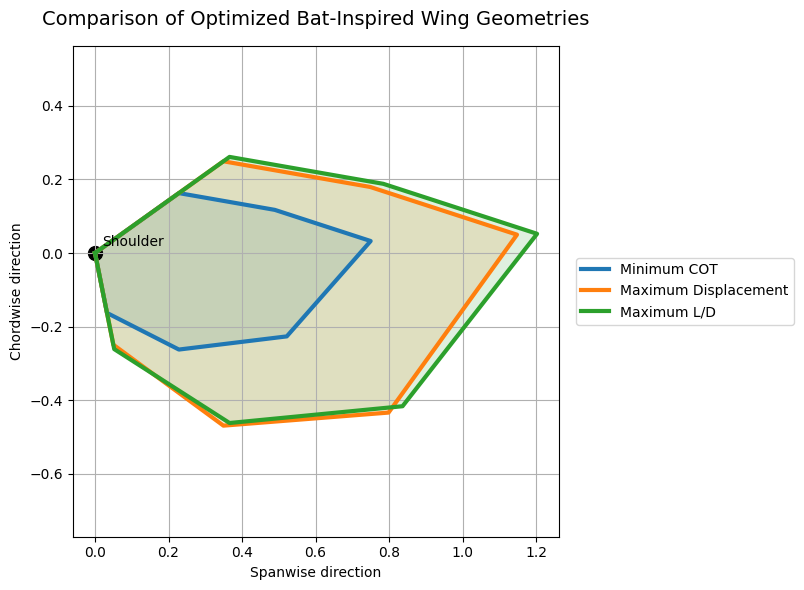

In [32]:
# Compare All Optimized Wing Geometries
def get_wing_geometry(x, result):

    km, kj, S = x

    scale = np.sqrt(S / 0.040)

    shoulder = np.array([0.0, 0.0])
    elbow    = scale * np.array([0.35, 0.25])
    wrist    = scale * np.array([0.75, 0.18])
    wingtip  = scale * np.array([1.15, 0.05])

    body_trailing  = scale * np.array([0.05, -0.25])
    inner_trailing = scale * np.array([0.35, -0.35])
    outer_trailing = scale * np.array([0.80, -0.28])

    eta_vis = result["max_eta"]

    inner_trailing_deformed = (
        inner_trailing
        + np.array([0.0, -0.35 * eta_vis])
    )

    outer_trailing_deformed = (
        outer_trailing
        + np.array([0.0, -0.45 * eta_vis])
    )

    membrane = np.array([
        shoulder,
        elbow,
        wrist,
        wingtip,
        outer_trailing_deformed,
        inner_trailing_deformed,
        body_trailing,
        shoulder
    ])

    return membrane


# Build all geometries
wing_cot = get_wing_geometry(x_opt, result_opt)
wing_dx  = get_wing_geometry(x_dx, result_dx)
wing_ld  = get_wing_geometry(x_ld, result_ld)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    wing_cot[:,0],
    wing_cot[:,1],
    linewidth=3,
    label="Minimum COT"
)

ax.plot(
    wing_dx[:,0],
    wing_dx[:,1],
    linewidth=3,
    label="Maximum Displacement"
)

ax.plot(
    wing_ld[:,0],
    wing_ld[:,1],
    linewidth=3,
    label="Maximum L/D"
)

# Filled transparent wings
ax.fill(
    wing_cot[:,0],
    wing_cot[:,1],
    alpha=0.15
)

ax.fill(
    wing_dx[:,0],
    wing_dx[:,1],
    alpha=0.15
)

ax.fill(
    wing_ld[:,0],
    wing_ld[:,1],
    alpha=0.15
)

# Shoulder location
ax.scatter(0, 0, s=100, color='k')
ax.text(
    0.02,
    0.02,
    "Shoulder",
    fontsize=10
)

ax.set_title(
    "Comparison of Optimized Bat-Inspired Wing Geometries",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Spanwise direction")
ax.set_ylabel("Chordwise direction")

ax.axis("equal")
ax.grid(True)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0,0,0.82,1])
plt.show()

In [33]:
# Table of Optimized Shape Variables
import pandas as pd

summary_table = pd.DataFrame({
    "Objective": [
        "Minimum COT",
        "Maximum Displacement",
        "Maximum Lift/Drag"
    ],

    "Membrane Stiffness (k_m)": [
        x_opt[0],
        x_dx[0],
        x_ld[0]
    ],

    "Joint Stiffness (k_j)": [
        x_opt[1],
        x_dx[1],
        x_ld[1]
    ],

    "Wing Area (S) [m²]": [
        x_opt[2],
        x_dx[2],
        x_ld[2]
    ],

    "Max Camber (eta) [rad]": [
        result_opt["max_eta"],
        result_dx["max_eta"],
        result_ld["max_eta"]
    ],

    "Mean Lift [N]": [
        result_opt["mean_lift"],
        result_dx["mean_lift"],
        result_ld["mean_lift"]
    ],

    "Mean Drag [N]": [
        result_opt["mean_drag"],
        result_dx["mean_drag"],
        result_ld["mean_drag"]
    ]
})

summary_table = summary_table.round(4)

print("\nOptimized Design Comparison\n")
display(summary_table)


Optimized Design Comparison



,Objective,Membrane Stiffness (k_m),Joint Stiffness (k_j),Wing Area (S) [m²],Max Camber (eta) [rad],Mean Lift [N],Mean Drag [N]
0,Minimum COT,0.2850,0.2990,0.0170,0.0983,0.9799,0.2496
1,Maximum Displacement,0.1990,0.2984,0.0399,0.3436,3.2423,0.8295
2,Maximum Lift/Drag,0.2696,0.3837,0.0437,0.2756,4.5157,0.8367
